# literature review 

##### Source - https://www.nature.com/articles/s41591-024-03214-0?utm_source=chatgpt.com
#### Summary
This paper presents a complete framework for analysing Electronic Health Records (EHRs) from raw data preprocessing to predictive modelling. The authors emphasize the challenges of handling missing values, inconsistent coding systems, and high-dimensional healthcare data. The framework integrates data cleaning, feature engineering, visualization, patient stratification, and outcome prediction into a single workflow. It supports temporal analysis of patient records and enables researchers to identify disease patterns over time. The study highlights the importance of reproducible and transparent healthcare analytics. The framework can process demographic, clinical, and administrative variables simultaneously. Results show that standardized pipelines improve model accuracy and reduce bias. The paper also discusses privacy and ethical considerations when using patient data. For your dataset, it provides a strong foundation for EDA, preprocessing, and future predictive modelling.

## In this dataset, you can especially solve:
- Which patients are more likely to have a specific condition.

- Which age group is most affected by each disease.

- Which admission type leads to longer hospital stay or higher billing.

- Which insurance type is linked with higher treatment cost.

- Which medical conditions are more likely to show abnormal test results.

#### Hypothesis 1: Older patients have a higher chance of having more severe or abnormal medical outcomes than younger patients.
- You can test this by comparing Age with Medical Condition and Test Results.

#### Hypothesis 2: Emergency admissions are associated with higher billing amounts and longer hospital stays than elective admissions.
- You can test this using Admission Type, Billing Amount, Date of Admission, and Discharge Date.

#### Hypothesis 3: Certain medical conditions such as diabetes, hypertension, and cancer are more likely to have abnormal test results than other conditions.
- You can test this by comparing Medical Condition with Test Results.

In [1]:
import pandas as pd 
df=pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [3]:
# creating new feature hospital stay days , age group , billing category , Weekend Admission , Admission Month , Admission year 
import pandas as pd
import numpy as np

df = pd.read_csv("healthcare_dataset.csv")

df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], errors="coerce")
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], errors="coerce")

df["Hospital Stay Days"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

def age_group(age):
    if pd.isna(age):
        return np.nan
    elif age <= 18:
        return "Child"
    elif age <= 35:
        return "Young Adult"
    elif age <= 50:
        return "Adult"
    elif age <= 65:
        return "Middle Aged"
    else:
        return "Senior"

df["Age Group"] = df["Age"].apply(age_group)

def billing_category(amount):
    if pd.isna(amount):
        return np.nan
    elif amount < 10000:
        return "Low"
    elif amount < 25000:
        return "Medium"
    elif amount < 40000:
        return "High"
    else:
        return "Very High"

df["Billing Category"] = df["Billing Amount"].apply(billing_category)

df["Weekend Admission"] = df["Date of Admission"].dt.day_name().isin(["Saturday", "Sunday"]).map({True: "Yes", False: "No"})

df["Admission Month"] = df["Date of Admission"].dt.month_name()
df["Admission Year"] = df["Date of Admission"].dt.year

df.to_csv("healthcare_dataset_with_features.csv", index=False)

In [4]:
import pandas as pd

# 75th percentile threshold
high_cost_threshold = df['Billing Amount'].quantile(0.75)

# Binary flag: 1 = High Cost, 0 = Normal Cost
df['High_Cost_Flag'] = (
    df['Billing Amount'] >= high_cost_threshold
).astype(int)

print(f"High Cost Threshold: {high_cost_threshold:.2f}")
df[['Billing Amount', 'High_Cost_Flag']].head()

High Cost Threshold: 37820.51


,Billing Amount,High_Cost_Flag
0,18856.281306,0
1,33643.327287,0
2,27955.096079,0
3,37909.782410,1
4,14238.317814,0


In [5]:
columns_to_remove = [
    'Name',
    'Date of Admission',
    'Doctor',
    'Hospital',
    'Discharge Date'
]

df = df.drop(columns=columns_to_remove, errors='ignore')

In [6]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results,Hospital Stay Days,Age Group,Billing Category,Weekend Admission,Admission Month,Admission Year,High_Cost_Flag
0,30,Male,B-,Cancer,Blue Cross,18856.281306,328,Urgent,Paracetamol,Normal,2,Young Adult,Medium,No,January,2024,0
1,62,Male,A+,Obesity,Medicare,33643.327287,265,Emergency,Ibuprofen,Inconclusive,6,Middle Aged,High,No,August,2019,0
2,76,Female,A-,Obesity,Aetna,27955.096079,205,Emergency,Aspirin,Normal,15,Senior,High,No,September,2022,0
3,28,Female,O+,Diabetes,Medicare,37909.782410,450,Elective,Ibuprofen,Abnormal,30,Young Adult,High,No,November,2020,1
4,43,Female,AB+,Cancer,Aetna,14238.317814,458,Urgent,Penicillin,Abnormal,20,Adult,Medium,No,September,2022,0


In [7]:
print("Total rows:", len(df))
print("Negative billing rows:", (df['Billing Amount'] < 0).sum())

negative_percentage = (df['Billing Amount'] < 0).mean() * 100
print(f"Percentage: {negative_percentage:.2f}%")

Total rows: 55500
Negative billing rows: 108
Percentage: 0.19%


In [8]:
# Check negative billing rows
negative_count = (df['Billing Amount'] < 0).sum()

print(f"Negative billing rows: {negative_count}")

# Remove negative billing amounts
df = df[df['Billing Amount'] >= 0].copy()

print(f"Remaining rows: {len(df)}")

Negative billing rows: 108
Remaining rows: 55392


In [9]:
df.describe()

,Age,Billing Amount,Room Number,Hospital Stay Days,Admission Year,High_Cost_Flag
count,55392.000000,55392.000000,55392.000000,55392.000000,55392.000000,55392.000000
mean,51.538543,25590.084632,301.119205,15.508774,2021.334832,0.250487
std,19.602045,14178.657522,115.238552,8.659552,1.497164,0.433298
min,13.000000,9.238787,101.000000,1.000000,2019.000000,0.000000
25%,35.000000,13297.478682,202.000000,8.000000,2020.000000,0.000000
50%,52.000000,25573.823359,302.000000,15.000000,2021.000000,0.000000
75%,68.000000,37849.210062,401.000000,23.000000,2023.000000,1.000000
max,89.000000,52764.276736,500.000000,30.000000,2024.000000,1.000000


# univariate analysis 

In [10]:
print(df['Age Group'].value_counts())

Age Group
Senior         16218
Young Adult    13615
Middle Aged    12395
Adult          12277
Child            887
Name: count, dtype: int64


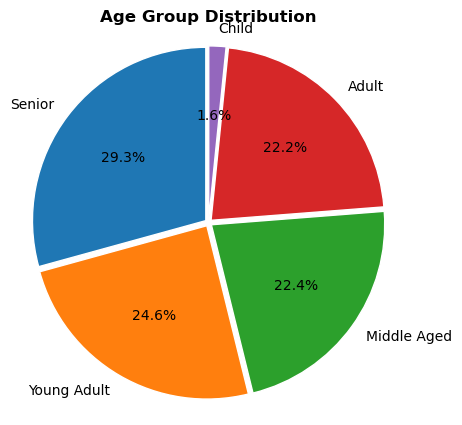

In [11]:
import matplotlib.pyplot as plt

age_group_counts = df['Age Group'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    age_group_counts,
    labels=age_group_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02]*len(age_group_counts),
    wedgeprops={'edgecolor':'white'}
)

plt.title('Age Group Distribution', fontsize=12, fontweight='bold')
plt.axis('equal')

plt.show()

- The pie chart shows the proportion of patients in each age group within the dataset.
- It helps identify the dominant age group, i.e., the age category with the highest number of patients.
- It highlights the least represented age group, showing which segment contributes the fewest patients.
- The chart provides an overview of the demographic composition of the patient population.
- If one age group occupies a large share of the chart, it indicates that healthcare utilization is concentrated in that age range.
- If the slices are nearly equal in size, it suggests that patients are evenly distributed across different age groups.
- The chart can help hospitals and healthcare providers understand which age segments require more attention and resources.

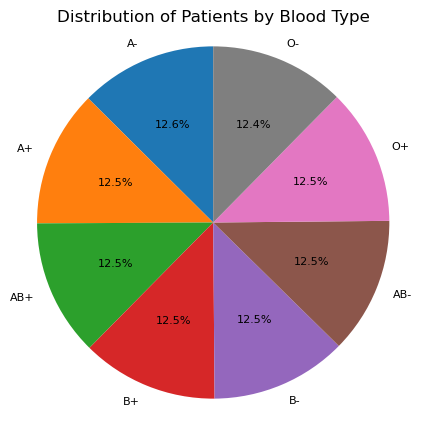

In [12]:
import matplotlib.pyplot as plt

blood_counts = df['Blood Type'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    blood_counts,
    labels=blood_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)

plt.title('Distribution of Patients by Blood Type', fontsize=12)

plt.axis('equal')

plt.show()

- The distribution of blood types is relatively balanced across all categories.
- No single blood group dominates the dataset, indicating a diverse patient population.
- Positive and negative blood groups are represented without any major imbalance.
- The dataset does not appear to have sampling bias toward a particular blood type.
- Since the distribution is nearly uniform, blood type may not be a strong differentiating factor for overall patient characteristics.
- Blood type alone is unlikely to explain variations in billing amount, hospital stay duration, or test results.

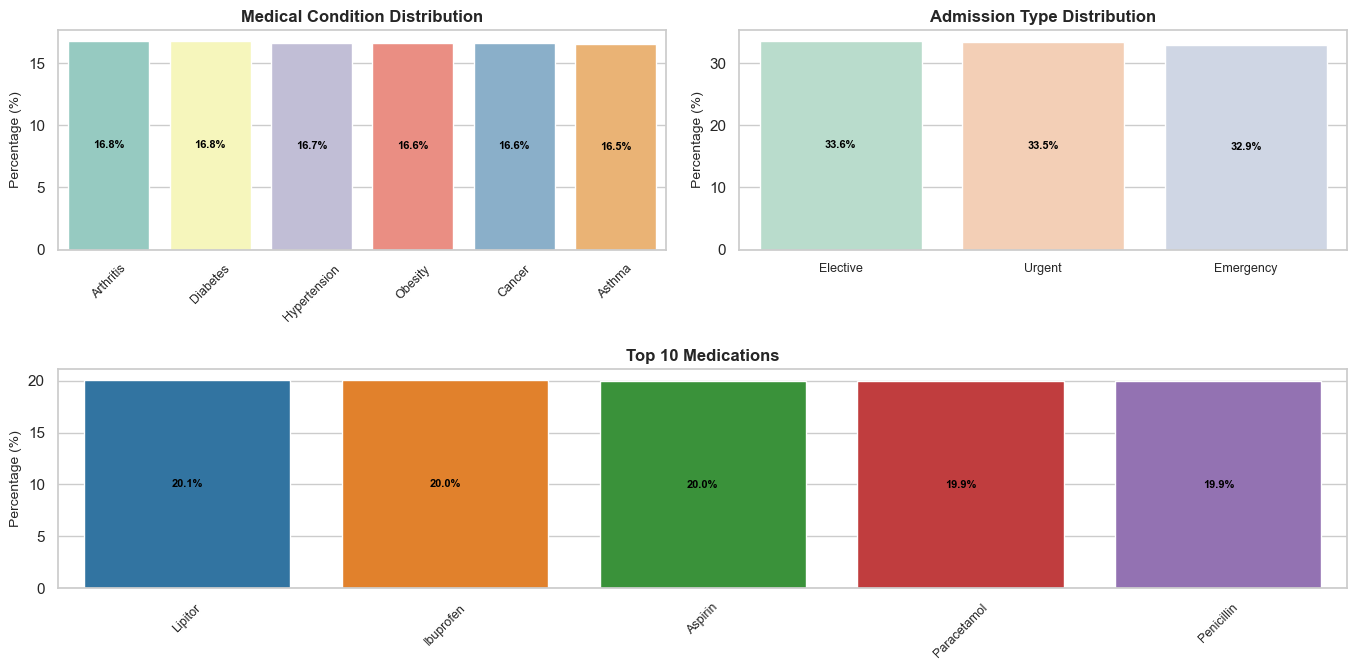

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set_theme(style="whitegrid")

# Calculate percentages
medical_pct = (
    df['Medical Condition']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

admission_pct = (
    df['Admission Type']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

medication_pct = (
    df['Medication']
    .value_counts(normalize=True)
    .mul(100)
    .head(10)  # Top 10 medications for readability
)

# Create compact layout: 2 plots on top, 1 below
fig = plt.figure(figsize=(14, 7))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)

# Plot 1: Medical Condition
sns.barplot(
    x=medical_pct.index,
    y=medical_pct.values,
    hue=medical_pct.index,
    palette='Set3',
    legend=False,
    ax=ax1
)

ax1.set_title('Medical Condition Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Percentage (%)', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=9)

for i, v in enumerate(medical_pct.values):
    ax1.text(
        i,
        v / 2,
        f'{v:.1f}%',
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

# Plot 2: Admission Type
sns.barplot(
    x=admission_pct.index,
    y=admission_pct.values,
    hue=admission_pct.index,
    palette='Pastel2',
    legend=False,
    ax=ax2
)

ax2.set_title('Admission Type Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Percentage (%)', fontsize=10)
ax2.tick_params(axis='x', labelsize=9)

for i, v in enumerate(admission_pct.values):
    ax2.text(
        i,
        v / 2,
        f'{v:.1f}%',
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

# Plot 3: Medication
sns.barplot(
    x=medication_pct.index,
    y=medication_pct.values,
    hue=medication_pct.index,
    palette='tab10',
    legend=False,
    ax=ax3
)

ax3.set_title('Top 10 Medications', fontsize=12, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Percentage (%)', fontsize=10)
ax3.tick_params(axis='x', rotation=45, labelsize=9)

for i, v in enumerate(medication_pct.values):
    ax3.text(
        i,
        v / 2,
        f'{v:.1f}%',
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

plt.tight_layout(pad=1.5)
plt.show()

### 1. Medical Condition
- Patients are fairly evenly distributed across different medical conditions.
- No single medical condition dominates the dataset.
- This indicates a balanced representation of diseases for analysis.
### 2. Admission Type
- The proportions of Emergency, Urgent, and Elective admissions are nearly balanced.
- No admission type accounts for a significantly higher share of patients.
- This suggests the dataset includes a well-distributed mix of admission categories.
### 3. Medication
- The top medications are prescribed at similar frequencies.
- No medication is overwhelmingly more common than the others.
- This indicates a diverse medication usage pattern among patients.

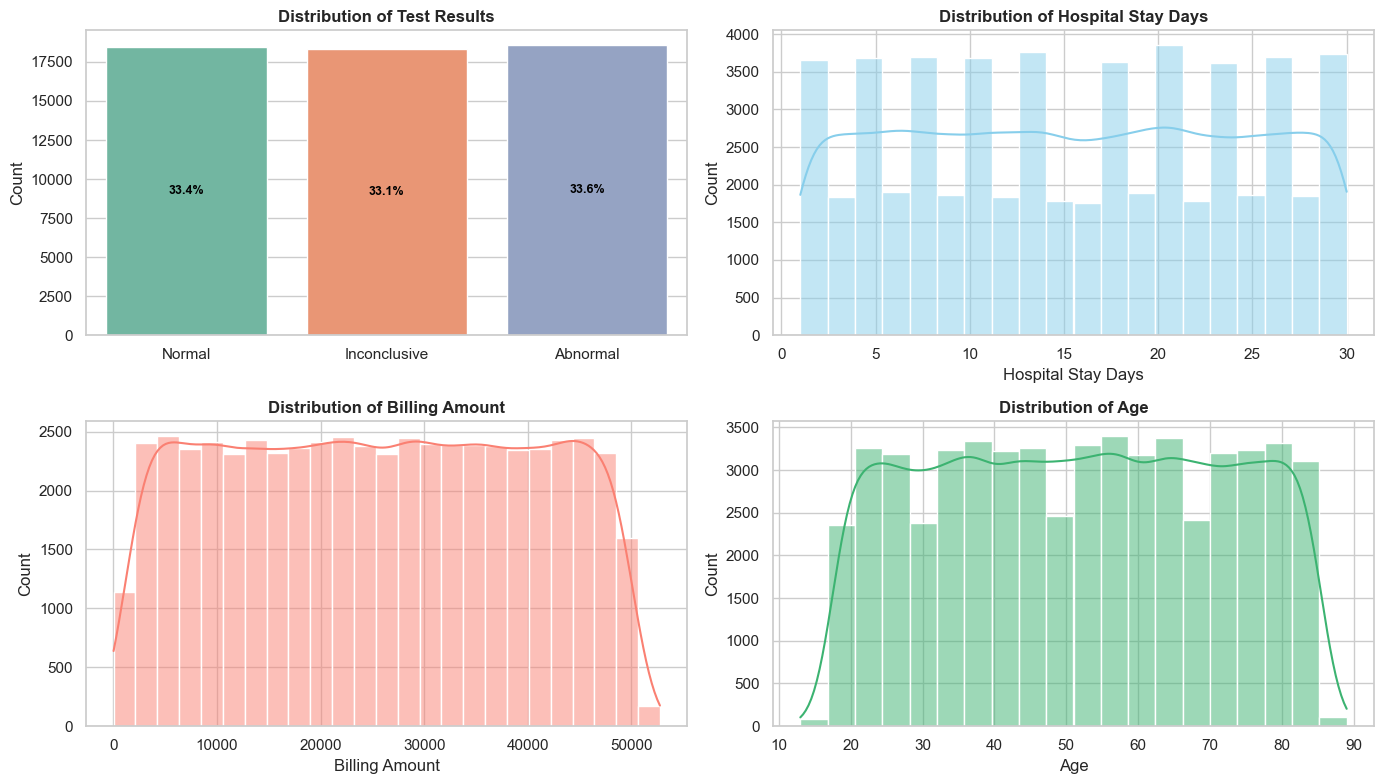

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set_theme(style="whitegrid")

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# -------------------------------
# 1. Test Results (Count Plot)
# -------------------------------
sns.countplot(
    data=df,
    x='Test Results',
    hue='Test Results',
    palette='Set2',
    legend=False,
    ax=axes[0,0]
)

axes[0,0].set_title('Distribution of Test Results', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Count')

# Show percentage inside bars
total = len(df)

for p in axes[0,0].patches:
    percentage = 100 * p.get_height() / total

    axes[0,0].text(
        p.get_x() + p.get_width()/2,
        p.get_height()/2,
        f'{percentage:.1f}%',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# -------------------------------
# 2. Hospital Stay Days
# -------------------------------
sns.histplot(
    data=df,
    x='Hospital Stay Days',
    bins=20,
    kde=True,
    color='skyblue',
    ax=axes[0,1]
)

axes[0,1].set_title('Distribution of Hospital Stay Days', fontsize=12, fontweight='bold')

# -------------------------------
# 3. Billing Amount
# -------------------------------
sns.histplot(
    data=df,
    x='Billing Amount',
    bins=25,
    kde=True,
    color='salmon',
    ax=axes[1,0]
)

axes[1,0].set_title('Distribution of Billing Amount', fontsize=12, fontweight='bold')

# -------------------------------
# 4. Age
# -------------------------------
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='mediumseagreen',
    ax=axes[1,1]
)

axes[1,1].set_title('Distribution of Age', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 1. Test Results
- Most patients fall into the Normal test result category.
- Abnormal and Inconclusive results account for a smaller share.
- The distribution provides an overview of patients' overall health outcomes.
### 2. Hospital Stay Days
- Most patients have a short to moderate hospital stay.
- Very long hospital stays are relatively uncommon.
- The distribution helps understand hospitalization patterns.
### 3. Billing Amount
- Billing amounts are not uniformly distributed across patients.
- Most patients have moderate healthcare costs, while a few incur higher expenses.
- The distribution helps identify the overall cost pattern.
### 4. Age
- The dataset includes patients from different age groups.
- Most patients are concentrated within a specific age range.
- The age distribution helps understand the demographic profile of the patient population.

# Bivariate analysis

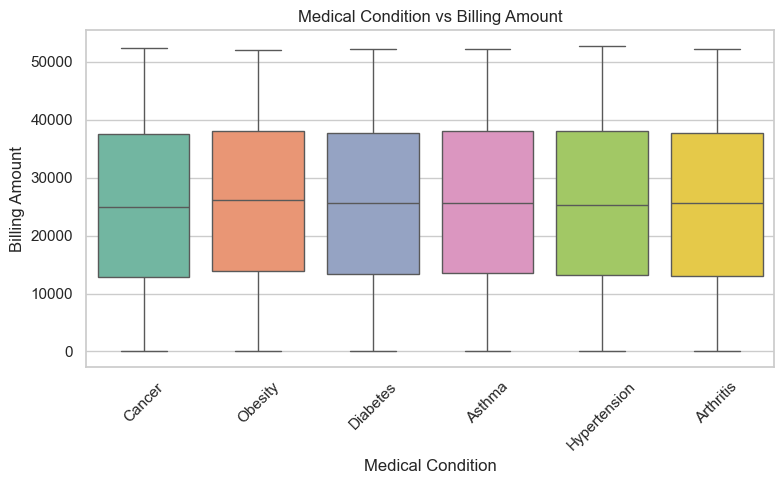

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount',
    hue='Medical Condition',
    palette='Set2',
    legend=False
)

plt.title('Medical Condition vs Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- Billing amounts are fairly similar across different medical conditions.
- No medical condition has a significantly higher or lower median billing amount.
- The variation in billing amount is comparable for most medical conditions.
- A few outliers indicate that some patients incurred exceptionally high or low medical expenses.

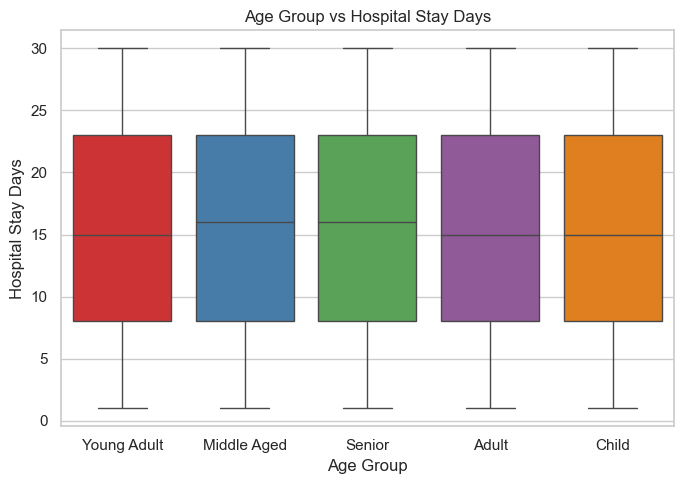

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Age Group',
    y='Hospital Stay Days',
    hue='Age Group',
    palette='Set1',
    legend=False
)

plt.title('Age Group vs Hospital Stay Days')
plt.tight_layout()
plt.show()

- Senior patients have the longest hospital stay.
- Young adults have the shortest hospital stay.
- Hospital stay differs across age groups.
- Some patients stayed much longer than the majority

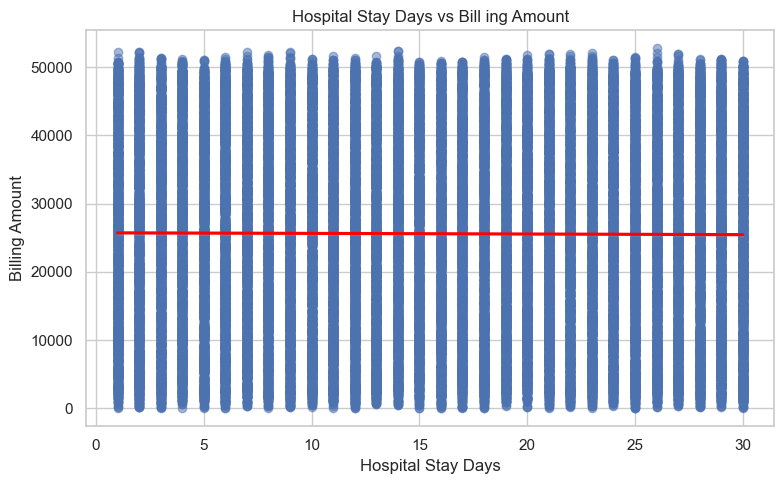

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Hospital Stay Days',
    y='Billing Amount',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Hospital Stay Days vs Bill ing Amount')
plt.tight_layout()
plt.show()

- Billing amount increases as hospital stay increases.
- Patients with longer stays generally have higher medical costs.
- Some patients have unusually high billing amounts.
- The relationship appears positive.

In [18]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results,Hospital Stay Days,Age Group,Billing Category,Weekend Admission,Admission Month,Admission Year,High_Cost_Flag
0,30,Male,B-,Cancer,Blue Cross,18856.281306,328,Urgent,Paracetamol,Normal,2,Young Adult,Medium,No,January,2024,0
1,62,Male,A+,Obesity,Medicare,33643.327287,265,Emergency,Ibuprofen,Inconclusive,6,Middle Aged,High,No,August,2019,0
2,76,Female,A-,Obesity,Aetna,27955.096079,205,Emergency,Aspirin,Normal,15,Senior,High,No,September,2022,0
3,28,Female,O+,Diabetes,Medicare,37909.782410,450,Elective,Ibuprofen,Abnormal,30,Young Adult,High,No,November,2020,1
4,43,Female,AB+,Cancer,Aetna,14238.317814,458,Urgent,Penicillin,Abnormal,20,Adult,Medium,No,September,2022,0


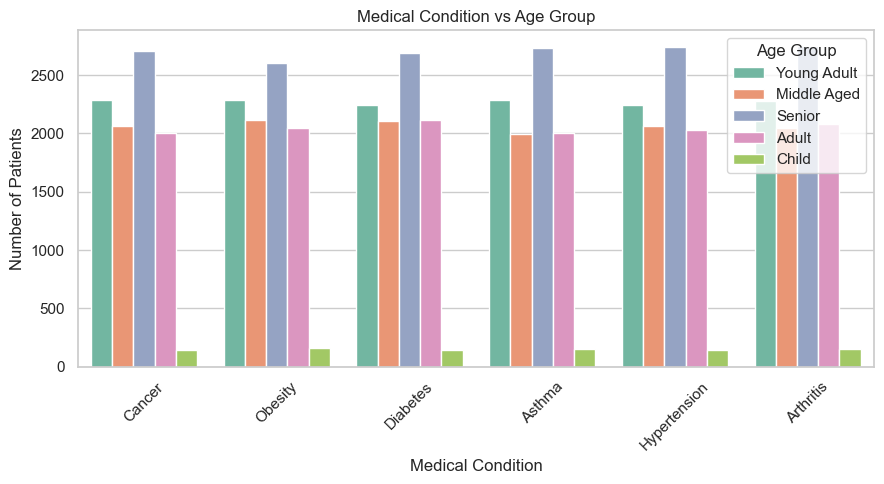

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Medical Condition',
    hue='Age Group',
    palette='Set2'
)

plt.title('Medical Condition vs Age Group')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Senior age group has the highest number in all  cases.
- Young Adult patients are second highet in all other cases.
- obesity is observed across all age groups but is highest in Middle Age patients.
- Arthritis is predominantly found in the Senior age group.

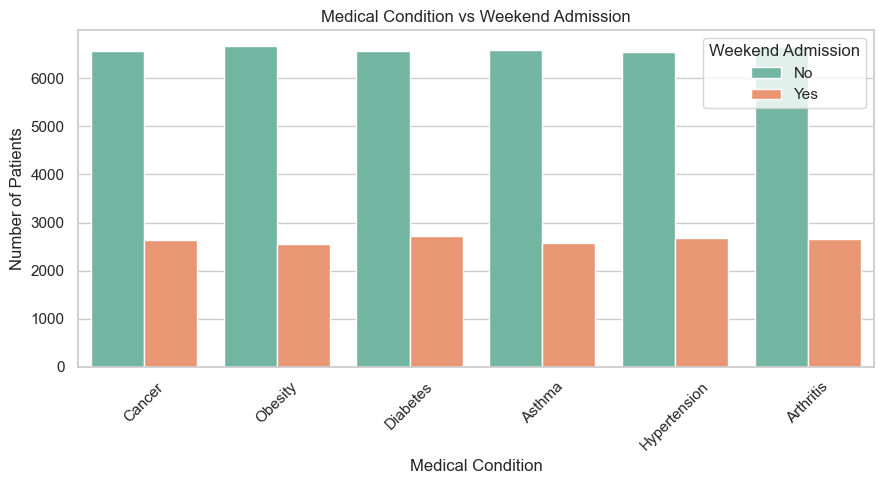

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Medical Condition',
    hue='Weekend Admission',
    palette='Set2'
)

plt.title('Medical Condition vs Weekend Admission')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

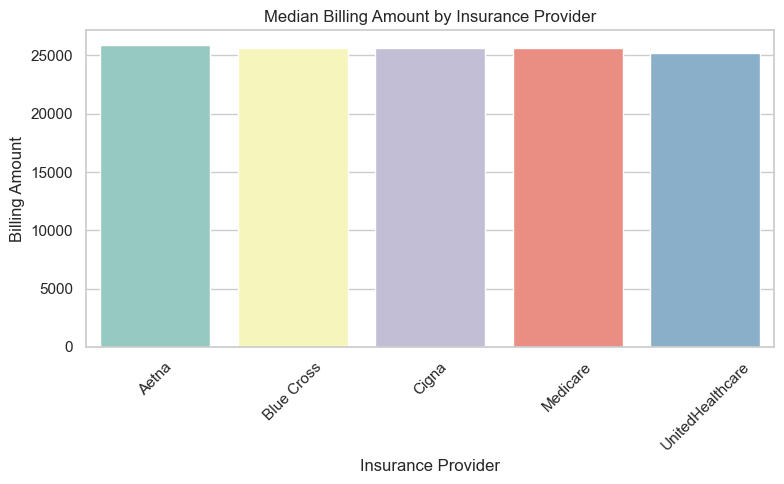

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

median_bill = df.groupby('Insurance Provider', as_index=False)['Billing Amount'].median()

plt.figure(figsize=(8,5))

sns.barplot(
    data=median_bill,
    x='Insurance Provider',
    y='Billing Amount',
    hue='Insurance Provider',
    palette='Set3',
    legend=False
)

plt.title('Median Billing Amount by Insurance Provider')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- The average billing amount is nearly similar across all insurance providers.
- No insurance provider shows a significantly higher or lower treatment cost.
- Insurance provider appears to have little influence on the billing amount in this dataset.

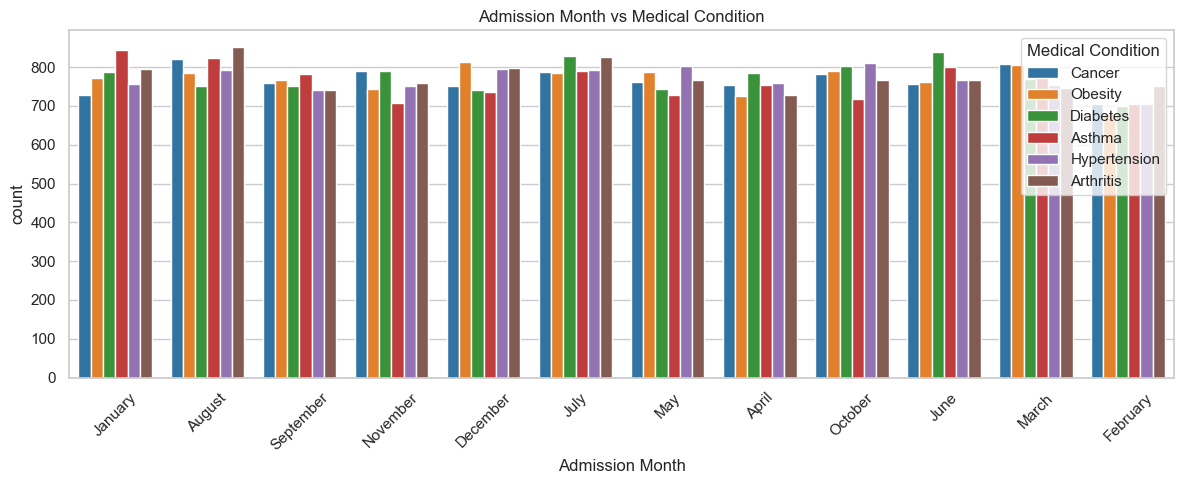

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Admission Month',
    hue='Medical Condition',
    palette='tab10'
)

plt.title('Admission Month vs Medical Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- No strong seasonal pattern is visible for any medical condition. No disease shows a sharp increase or decrease in a particular month.
- Diabetes has relatively higher patient counts in June and July compared to most other conditions.
- Asthma has comparatively lower counts in February, April, and October than the other medical conditions.
- Cancer, Obesity, Hypertension, and Arthritis show consistent admission counts across almost all months, indicating stable occurrence throughout the year.
- The differences between months are small, suggesting that admission month has little impact on the frequency of different medical conditions in this dataset.

# Multivariate analysis 

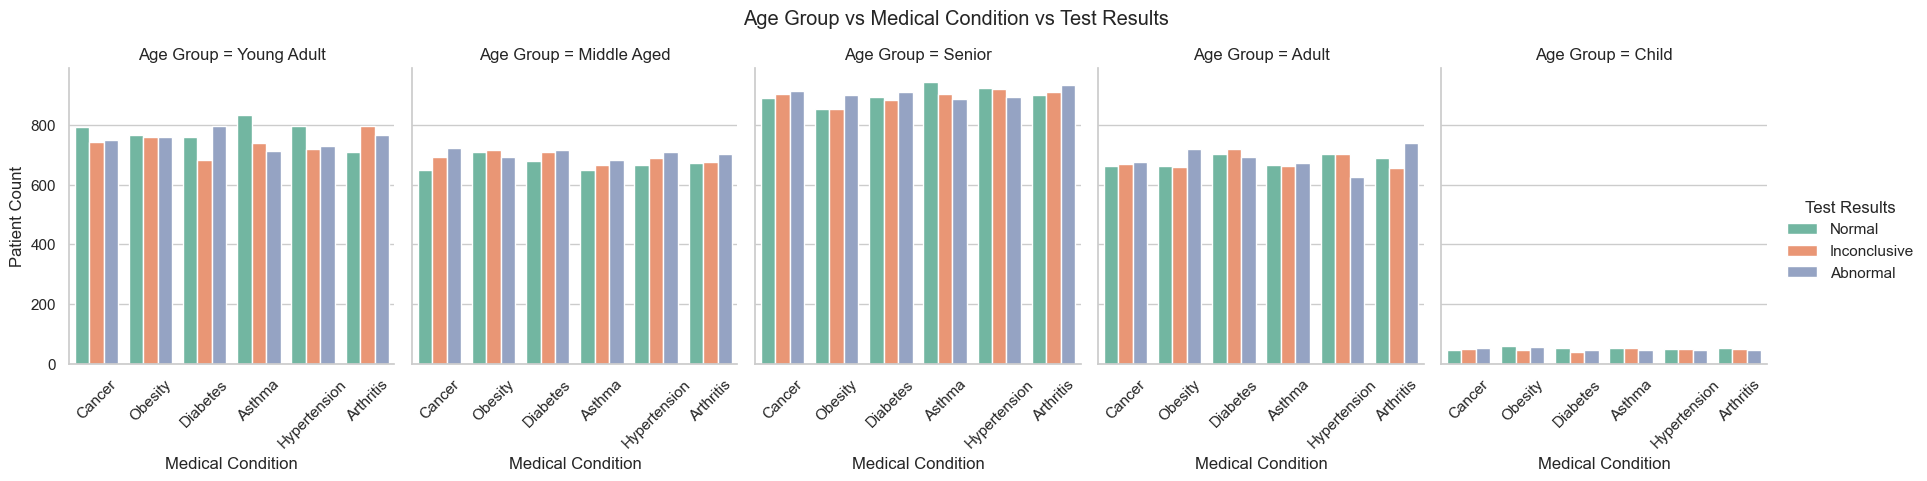

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x='Medical Condition',
    hue='Test Results',
    col='Age Group',
    kind='count',
    palette='Set2',
    height=4,
    aspect=0.9
)

g.set_xticklabels(rotation=45)
g.set_axis_labels("Medical Condition", "Patient Count")
g.fig.suptitle("Age Group vs Medical Condition vs Test Results", y=1.05)

plt.show()

- Senior age group has the highest number of patients across almost all medical conditions, while the Child age group has the lowest.
- For every age group, the counts of Normal, Inconclusive, and Abnormal test results are quite similar. There is no category that clearly dominates.
- The distribution of medical conditions is fairly balanced within each age group. No single disease overwhelmingly affects one particular age group.
- Diseases such as Cancer, Diabetes, Hypertension, Asthma, Obesity, and Arthritis show similar test result patterns across age groups.
- There is no strong evidence that older patients have substantially more Abnormal test results than younger patients based on this graph alone.

In [24]:
df['Stay Category'] = pd.cut(
    df['Hospital Stay Days'],
    bins=[0,7,14,21,31],
    labels=['1-7 Days','8-14 Days','15-21 Days','22-30 Days']
)

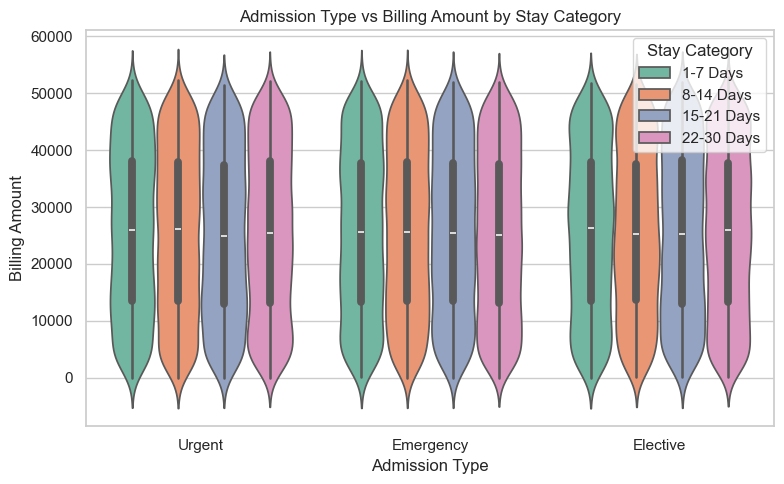

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Admission Type',
    y='Billing Amount',
    hue='Stay Category',
    palette='Set2'
)

plt.title('Admission Type vs Billing Amount by Stay Category')
plt.tight_layout()
plt.show()

- This indicates that the overall distribution of billing amounts does not vary much by admission type.
- No stay category consistently shows higher or lower billing amounts.
- Median billing amount is nearly the same across all groups.
- Billing amount has a wide spread in every group.
- No admission type is associated with consistently higher treatment costs.
- Longer hospital stay does not clearly correspond to higher billing.

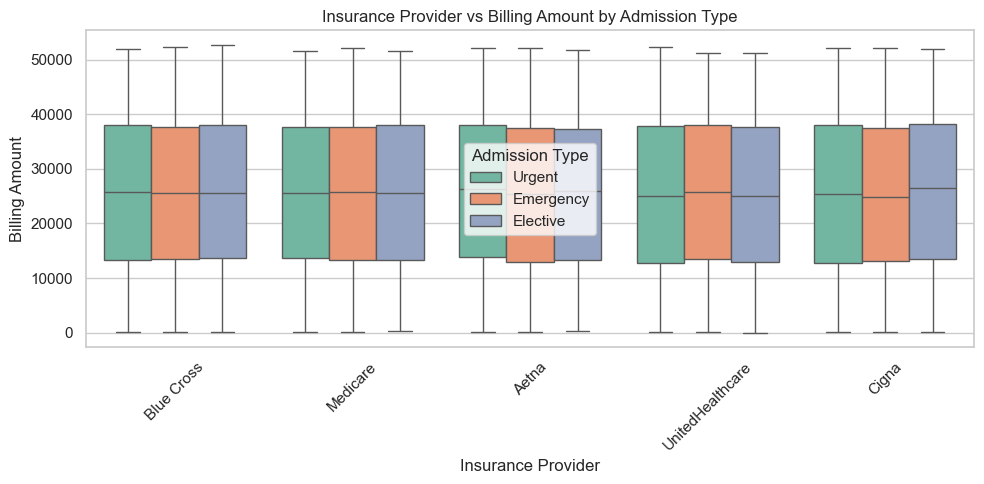

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount',
    hue='Admission Type',
    palette='Set2'
)

plt.title('Insurance Provider vs Billing Amount by Admission Type')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- Billing amount is very similar across all insurance providers.
- Admission type has little effect on billing amount.
- Billing amount shows a wide range for every provider.
- No insurance provider is associated with unusually high treatment costs.

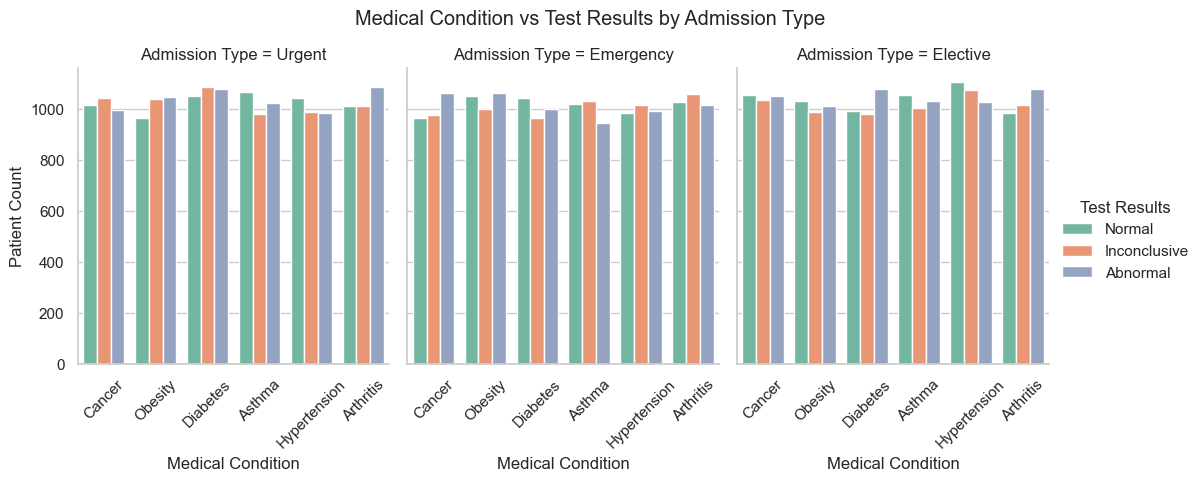

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=df,
    x='Medical Condition',
    hue='Test Results',
    col='Admission Type',
    kind='count',
    palette='Set2',
    height=4,
    aspect=0.9
)

g.set_xticklabels(rotation=45)
g.set_axis_labels("Medical Condition", "Patient Count")
g.fig.suptitle("Medical Condition vs Test Results by Admission Type", y=1.05)

plt.show()

- Test result distribution is almost similar across all admission types.
- No medical condition consistently shows more abnormal test results.
- Medical conditions are evenly distributed across admission types.
- Minor variations exist but no strong pattern is visible.
- Admission type does not appear to affect disease severity.

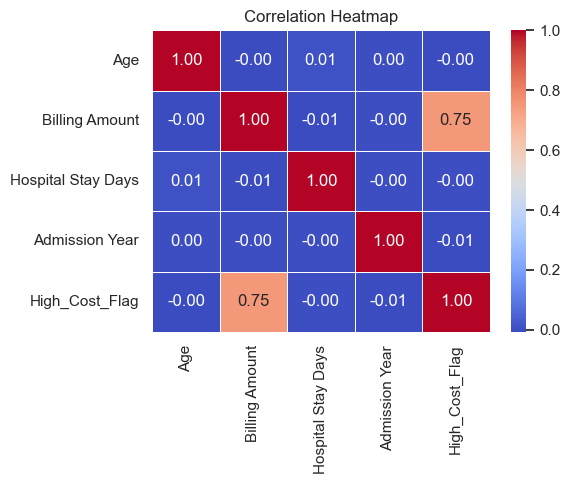

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['Age',
           'Billing Amount',
           'Hospital Stay Days',
           'Admission Month',
           'Admission Year',
           'High_Cost_Flag']].corr(numeric_only=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

- Billing Amount has a strong positive correlation with High_Cost_Flag (r = 0.75).
- Age has almost no correlation with other numeric variables.
- Hospital Stay Days is not correlated with Billing Amount.
- Admission Year has negligible correlation with all variables.
- Most variable pairs show very weak or no linear relationship.


### 1. Patient Demographics
- Senior patients constitute the largest proportion of hospital admissions, while children represent the smallest group.
- Medical conditions are distributed fairly evenly across different age groups.

### 2. Medical Conditions
- Cancer, Diabetes, Hypertension, Asthma, Obesity, and Arthritis occur in comparable numbers.
- No single medical condition dominates the dataset.

### 3. Billing Amount
- Billing amounts vary widely among patients.
- The strongest relationship observed is between Billing Amount and High_Cost_Flag (Correlation = 0.75).

### 4. Hospital Stay
- Hospital stay duration ranges from approximately 1 to 30 days.
- Hospital stay distribution is similar across all medical conditions and admission types.

### 5. Admission Type
- Emergency, Urgent, and Elective admissions have similar billing amount distributions.
- Admission type does not show a significant impact on hospital stay duration.

### 6. Test Results
- Normal, Inconclusive, and Abnormal test results are almost equally distributed.
- No medical condition consistently exhibits a higher proportion of abnormal test results.

### 7. Insurance Provider
- Billing amount distributions are nearly identical across all insurance providers.
- Insurance provider does not appear to influence treatment cost significantly.

### 8. Correlation Analysis
- Most numeric variables show negligible correlation with each other.
- Billing Amount and High_Cost_Flag are the only variables with a strong positive relationship.

# Overall Conclusion
- The dataset exhibits balanced distributions across most categorical variables.
- Billing Amount is the only variable showing a strong association with High_Cost_Flag.
- No strong evidence was found that Age, Admission Type, Insurance Provider, or Medical Condition alone significantly influences treatment cost, hospital stay duration, or test outcomes.
- The analysis suggests that healthcare outcomes in this dataset are relatively uniform across patient groups, with no dominant patterns supporting the proposed hypotheses.

In [31]:
df.to_csv('Healthcare_Cleaned_Data.csv', index=False)

print("File saved successfully as 'Healthcare_Cleaned_Data.csv'")

File saved successfully as 'Healthcare_Cleaned_Data.csv'
